# Spectral Granger Causality on NHP LFP Recordings

This notebook applies bivariate Granger causality (GC) analysis to real
non-human primate (NHP) local field potential (LFP) recordings comprising
**332 trials**, **2 regions of interest (ROIs)**, and **2150 samples per trial**
acquired at **1000 Hz**. GC is computed four ways — one parametric (VAR) estimate
and three non-parametric estimates that differ only in how the cross-spectral
matrix is formed:

| method | estimator | notes |
| --- | --- | --- |
| `model='parametric'` | VAR model + analytic transfer function | requires a model `order` |
| `spectral_method='welch'` | Welch overlapping-window average | robust averaging with fixed `nperseg` |
| `spectral_method='fourier'` | trial-averaged FFT periodogram | maximum frequency resolution |
| `spectral_method='multitaper'` | multitaper (DPSS) CSD via MNE | reduced spectral leakage; `bandwidth` controls smoothing |

The recordings show a prominent interaction around **35 Hz**. All four estimates
agree that it is directional: `GC(X→Y)` carries a clear peak near 35 Hz that
exceeds the reverse direction `GC(Y→X)`, so the coupling reflects a driving
relationship rather than symmetric synchronisation.

The data is one channel pair from the dataset of Dotson et al. (2017),
[doi:10.1016/j.neuron.2017.09.050](https://doi.org/10.1016/j.neuron.2017.09.050).

In [1]:
import os
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")  # quiet XLA's GPU memory probe

import matplotlib.pyplot as plt
import xarray as xr

from pygc.granger import spectral_granger_causality

plt.rcParams.update({"figure.dpi": 100, "font.size": 12})

In [2]:
data = xr.load_dataarray("data/data.nc")

In [3]:
FS = data.attrs["fsample"]  # sampling rate (Hz)
BANDWIDTH = 4.0              # multitaper bandwidth (Hz)
FMAX = 80                    # max frequency for plots

data_np = data.values  # (trials, roi, time) numpy array
print(f"Data: {data_np.shape[0]} trials, {data_np.shape[1]} channels, "
      f"{data_np.shape[2]} samples  @ {FS:.0f} Hz")

Data: 332 trials, 2 channels, 2150 samples  @ 1000 Hz


## Granger Causality — Parametric method


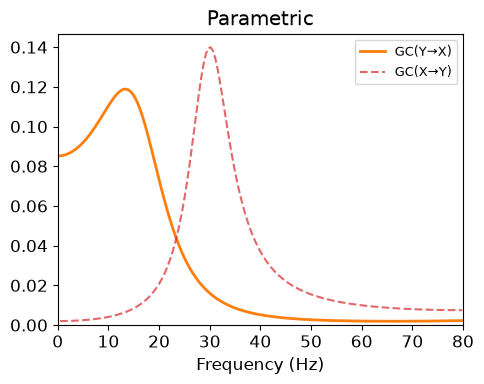

In [4]:
ds_pr = spectral_granger_causality(
    data_np, FS, model="parametric", order=6, verbose=False,
)

Ix2y_pr, Iy2x_pr, f_pr = ds_pr["x2y"][0], ds_pr["y2x"][0], ds_pr["freq"]

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
mask = f_pr <= FMAX
ax.plot(f_pr[mask], Iy2x_pr[mask], color="C1", lw=2, label="GC(Y→X)")
ax.plot(f_pr[mask], Ix2y_pr[mask], color="C3", lw=1.5,
        linestyle="--", alpha=0.7, label="GC(X→Y)")
ax.set_title("Parametric")
ax.set_xlabel("Frequency (Hz)")
ax.set_xlim([0, FMAX])
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
plt.tight_layout()

## Granger Causality — Welch method


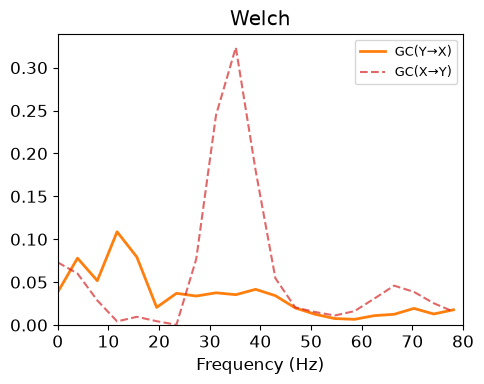

In [5]:
ds_wl = spectral_granger_causality(
    data_np, FS, spectral_method="welch", Niterations=200, verbose=False,
)

Ix2y_wl, Iy2x_wl, f_wl = ds_wl["x2y"][0], ds_wl["y2x"][0], ds_wl["freq"]

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
mask = f_wl <= FMAX
ax.plot(f_wl[mask], Iy2x_wl[mask], color="C1", lw=2, label="GC(Y→X)")
ax.plot(f_wl[mask], Ix2y_wl[mask], color="C3", lw=1.5,
        linestyle="--", alpha=0.7, label="GC(X→Y)")
ax.set_title("Welch")
ax.set_xlabel("Frequency (Hz)")
ax.set_xlim([0, FMAX])
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
plt.tight_layout()

## Granger Causality — Fourier method


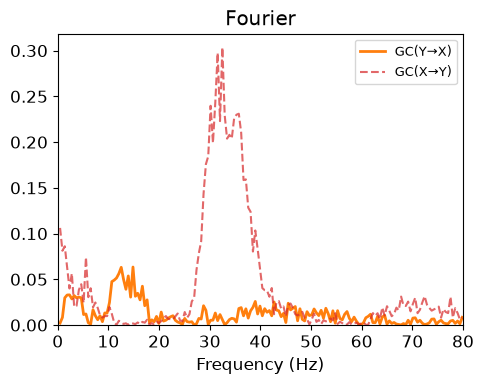

In [6]:
ds_fft = spectral_granger_causality(
    data_np, FS, spectral_method="fourier", Niterations=200, verbose=False,
)

Ix2y_fft, Iy2x_fft, f_fft = ds_fft["x2y"][0], ds_fft["y2x"][0], ds_fft["freq"]


fig, ax = plt.subplots(1, 1, figsize=(5, 4))
mask = f_fft <= FMAX
ax.plot(f_fft[mask], Iy2x_fft[mask], color="C1", lw=2, label="GC(Y→X)")
ax.plot(f_fft[mask], Ix2y_fft[mask], color="C3", lw=1.5,
        linestyle="--", alpha=0.7, label="GC(X→Y)")
ax.set_title("Fourier")
ax.set_xlabel("Frequency (Hz)")
ax.set_xlim([0, FMAX])
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
plt.tight_layout()

## Granger Causality — Multitaper method

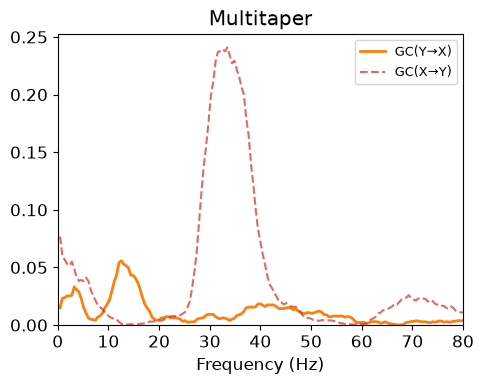

In [7]:
ds_mt = spectral_granger_causality(
    data_np, FS, spectral_method="multitaper", Niterations=200, verbose=False,
    spectral_params={"bandwidth": BANDWIDTH},
)

Ix2y_mt, Iy2x_mt, f_mt = ds_mt["x2y"][0], ds_mt["y2x"][0], ds_mt["freq"]

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
mask = f_mt <= FMAX
ax.plot(f_mt[mask], Iy2x_mt[mask], color="C1", lw=2, label="GC(Y→X)")
ax.plot(f_mt[mask], Ix2y_mt[mask], color="C3", lw=1.5,
        linestyle="--", alpha=0.7, label="GC(X→Y)")
ax.set_title("Multitaper")
ax.set_xlabel("Frequency (Hz)")
ax.set_xlim([0, FMAX])
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
plt.tight_layout()

## Comparison: All Four Methods


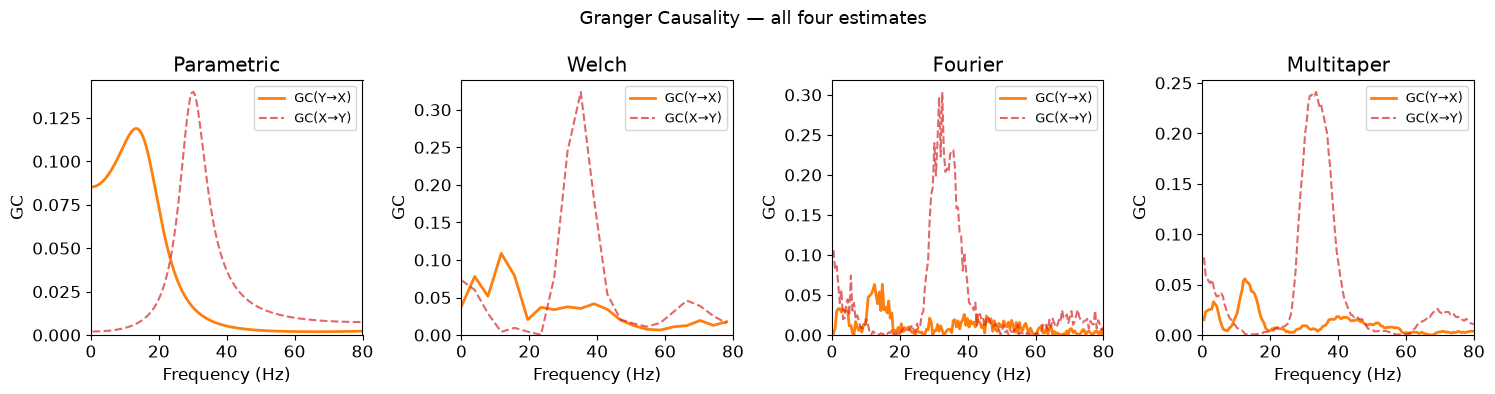

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

methods = [
    ("Parametric", f_pr,  Iy2x_pr,  Ix2y_pr),
    ("Welch",      f_wl,  Iy2x_wl,  Ix2y_wl),
    ("Fourier",    f_fft, Iy2x_fft, Ix2y_fft),
    ("Multitaper", f_mt,  Iy2x_mt,  Ix2y_mt),
]

for ax, (title, f, iy2x, ix2y) in zip(axes, methods):
    mask = f <= FMAX
    ax.plot(f[mask], iy2x[mask], color="C1", lw=2, label="GC(Y\u2192X)")
    ax.plot(f[mask], ix2y[mask], color="C3", lw=1.5,
            linestyle="--", alpha=0.7, label="GC(X\u2192Y)")
    ax.set_title(title)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("GC")
    ax.set_xlim([0, FMAX])
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9)

plt.suptitle("Granger Causality — all four estimates", fontsize=13)
plt.tight_layout()

## Summary

All four estimators agree on the direction of influence: `GC(X→Y)` has a clear peak at **30–35 Hz** (≈ 0.24–0.32 nats for Welch, Fourier and multitaper), while `GC(Y→X)` stays weak and confined below ~15 Hz. Welch gives the sharpest peak (fixed `nperseg`), multitaper the smoothest; the `order=6` parametric fit reproduces the same asymmetry with less spectral detail.